# 04 EDA — Graphic Novels

Goal:
Explore the cleaned graphic novel dataset and create visuals for the final report.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [14]:
df = pd.read_csv("../Data/Clean/merged_graphic_novels.csv")

df.shape

(351, 16)

In [15]:
# Display the first few rows of the DataFrame to check the data
report_dir = Path("../Reports/EDA_Graphic_Novels")
report_dir.mkdir(parents=True, exist_ok=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               351 non-null    object 
 1   author              351 non-null    object 
 2   first_publish_year  349 non-null    float64
 3   publisher           0 non-null      float64
 4   language            344 non-null    object 
 5   subject             0 non-null      float64
 6   isbn                0 non-null      float64
 7   cover_i             300 non-null    float64
 8   description         351 non-null    object 
 9   search_term         351 non-null    object 
 10  ol_key              351 non-null    object 
 11  filter_text         351 non-null    object 
 12  clean_description   351 non-null    object 
 13  clean_subject       0 non-null      float64
 14  combined_text       351 non-null    object 
 15  cover_url           300 non-null    object 
dtypes: float

In [17]:
df.isna().sum()

title                   0
author                  0
first_publish_year      2
publisher             351
language                7
subject               351
isbn                  351
cover_i                51
description             0
search_term             0
ol_key                  0
filter_text             0
clean_description       0
clean_subject         351
combined_text           0
cover_url              51
dtype: int64

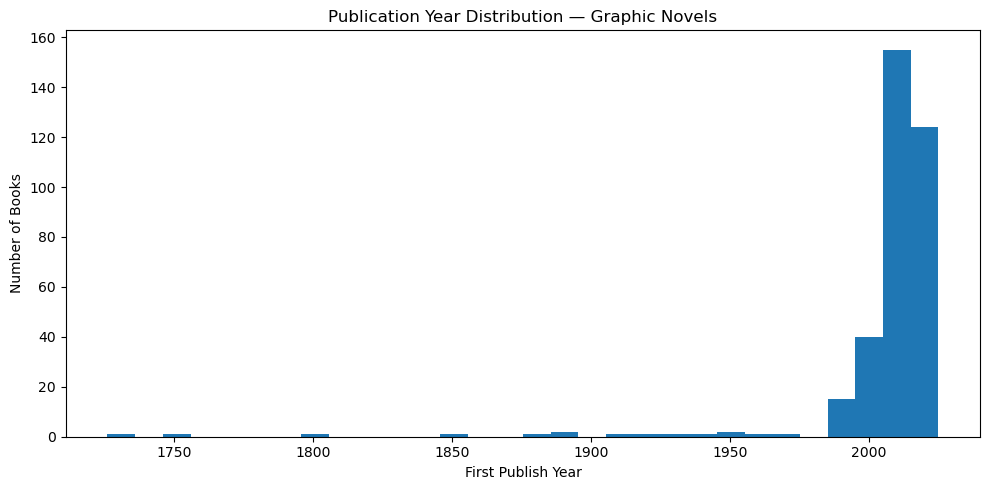

In [18]:
# Analyze publication years
years = df["first_publish_year"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(years, bins=30)
plt.title("Publication Year Distribution — Graphic Novels")
plt.xlabel("First Publish Year")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig(report_dir / "01_publication_years.png")
plt.show()

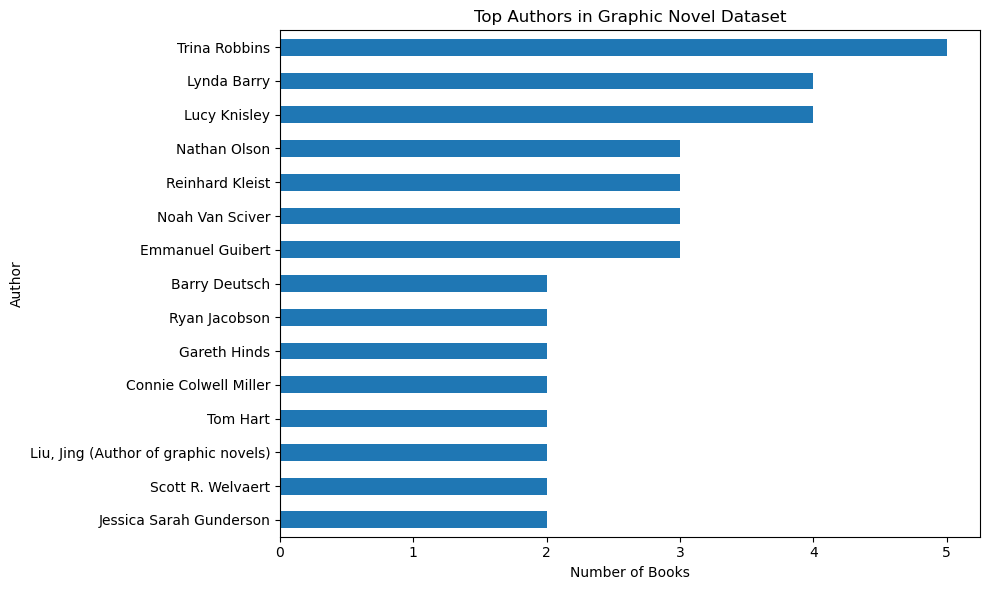

In [19]:
# Analyze top authors
top_authors = df["author"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_authors.sort_values().plot(kind="barh")
plt.title("Top Authors in Graphic Novel Dataset")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.tight_layout()
plt.savefig(report_dir / "02_top_authors.png")
plt.show()

In [20]:
# Analyze common words in descriptions
all_text = " ".join(df["clean_description"].dropna())

words = all_text.split()

stopwords = set([
    "the", "and", "of", "to", "a", "in", "is", "for", "with", "on", "as",
    "by", "an", "from", "this", "that", "it", "be", "are", "at", "or",
    "his", "her", "their", "its", "into", "about", "new", "one", "book"
])

filtered_words = [word for word in words if word not in stopwords and len(word) > 3]

word_counts = Counter(filtered_words).most_common(20)

word_counts

[('graphic', 418),
 ('novel', 226),
 ('comics', 173),
 ('story', 139),
 ('life', 128),
 ('history', 111),
 ('world', 108),
 ('comic', 95),
 ('most', 81),
 ('first', 80),
 ('have', 80),
 ('through', 75),
 ('work', 75),
 ('format', 74),
 ('american', 71),
 ('illustrated', 70),
 ('they', 68),
 ('novels', 68),
 ('stories', 67),
 ('more', 65)]

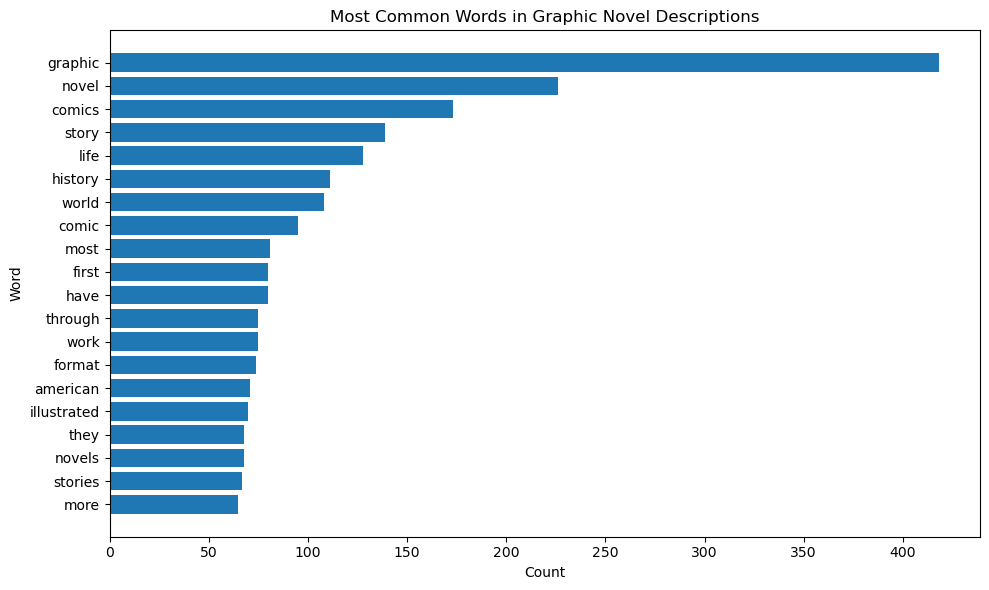

In [21]:
# Convert to DataFrame for plotting
words_df = pd.DataFrame(word_counts, columns=["word", "count"])

plt.figure(figsize=(10, 6))
plt.barh(words_df["word"], words_df["count"])
plt.title("Most Common Words in Graphic Novel Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(report_dir / "03_description_words.png")
plt.show()

In [22]:
# Analyze themes based on keywords in descriptions
theme_keywords = {
    "memoir": "memoir",
    "history": "history",
    "war": "war",
    "family": "family",
    "identity": "identity",
    "politics": "politic",
    "love": "love",
    "death": "death",
    "art": "art",
    "life": "life"
}

theme_counts = {}

for theme, keyword in theme_keywords.items():
    theme_counts[theme] = df["combined_text"].str.contains(keyword, case=False, na=False).sum()

theme_counts

{'memoir': 47,
 'history': 80,
 'war': 97,
 'family': 39,
 'identity': 14,
 'politics': 30,
 'love': 61,
 'death': 18,
 'art': 209,
 'life': 105}

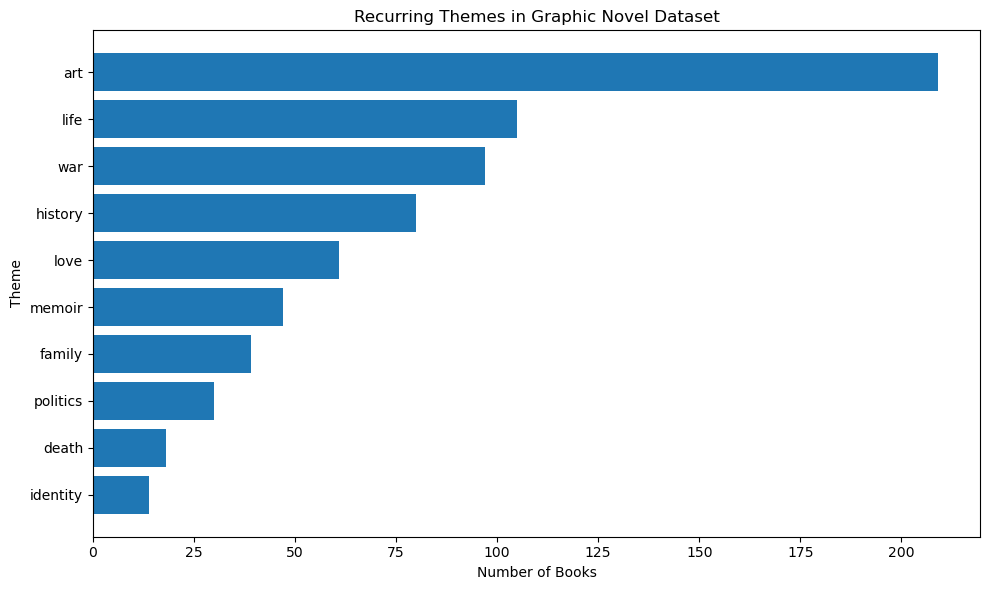

In [23]:
# Convert to DataFrame for plotting
theme_df = pd.DataFrame(
    list(theme_counts.items()),
    columns=["theme", "count"]
).sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(theme_df["theme"], theme_df["count"])
plt.title("Recurring Themes in Graphic Novel Dataset")
plt.xlabel("Number of Books")
plt.ylabel("Theme")
plt.tight_layout()
plt.savefig(report_dir / "04_theme_counts.png")
plt.show()

In [24]:
# Create a summary of key statistics
summary = {
    "total_books": len(df),
    "unique_authors": df["author"].nunique(),
    "earliest_year": df["first_publish_year"].min(),
    "latest_year": df["first_publish_year"].max(),
    "books_with_cover": df["cover_url"].notna().sum()
}

summary

{'total_books': 351,
 'unique_authors': 318,
 'earliest_year': 1726.0,
 'latest_year': 2025.0,
 'books_with_cover': 300}